In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"C:\Users\shreyaash mogaveera\sentiment-analysis-nlp\data\processed_reviews.csv")

In [4]:
df.head()

,processed_review,label
0,one reviewer mentioned watching oz episode you...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
3,basically there family little boy jake think t...,0
4,petter matteis love time money visually stunni...,1


In [5]:
X=df['processed_review']
y=df['label']

In [7]:
#train test split, using stratify to maintain class balance
from sklearn.model_selection import train_test_split,cross_val_score
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

## Text Vectorization

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=50000,ngram_range=(1,2),min_df=2,max_df=0.95,sublinear_tf=True)

In [16]:
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)

## model comparison and training

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve

In [13]:
models={
    'Logistic Regression':LogisticRegression(max_iter=1000, C=1.0),
    'Naive Bayes (Multinomial)': MultinomialNB(alpha=0.1),
    'Naive Bayes (Complement)': ComplementNB(alpha=0.1),
    'Linear SVC': LinearSVC(C=1.0, max_iter=2000)
}

In [15]:
results={}
for name,model in models.items():
    model.fit(X_train_tfidf,y_train)
    y_pred=model.predict(X_test_tfidf)
    acc=accuracy_score(y_test, y_pred)
    results[name]=acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.9037
Naive Bayes (Multinomial): 0.8835
Naive Bayes (Complement): 0.8835
Linear SVC: 0.9063


In [18]:
#Hyperparameters tuning for tfidf
tfidf_params=[
    {'max_features':30000,'ngram_range':(1,1)},
    {'max_features':50000,'ngram_range':(1,1)},
    {'max_features':100000,'ngram_range':(1,2)},
    {'max_features':50000,'ngram_range':(1,3)}
]
for params in tfidf_params:
    tfidf_test=TfidfVectorizer(**params,min_df=2,max_df=0.95,sublinear_tf=True)
    X_tr=tfidf_test.fit_transform(X_train)
    X_te=tfidf_test.transform(X_test)

    model=LinearSVC(C=1.0, max_iter=2000)
    model.fit(X_tr,y_train)
    acc=accuracy_score(y_test,model.predict(X_te))
    print(f"{params}: {acc:.4f}")

{'max_features': 30000, 'ngram_range': (1, 1)}: 0.8923
{'max_features': 50000, 'ngram_range': (1, 1)}: 0.8955
{'max_features': 100000, 'ngram_range': (1, 2)}: 0.9089
{'max_features': 50000, 'ngram_range': (1, 3)}: 0.9059


In [19]:
tfidf=TfidfVectorizer(max_features=100000,ngram_range=(1,2),min_df=2,max_df=0.95,sublinear_tf=True)
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)

In [21]:
#Hyperparameter tuning for linear SVC
from sklearn.model_selection import GridSearchCV
param_grid={
    'C':[0.01,0.1,1,5,10],
    'max_iter':[1000,2000]
}
svc_base=LinearSVC(random_state=42)
grid_search=GridSearchCV(svc_base,param_grid,cv=5,scoring='accuracy',n_jobs=-1,verbose=1)
grid_search.fit(X_train_tfidf,y_train)
print(f"Best Params: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

best_svc=grid_search.best_estimator_
y_pred_tuned=best_svc.predict(X_test_tfidf)
print(f"Test accuracy: {accuracy_score(y_test,y_pred_tuned):.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'C': 1, 'max_iter': 1000}
Best CV score: 0.9043
Test accuracy: 0.9089


## Plots

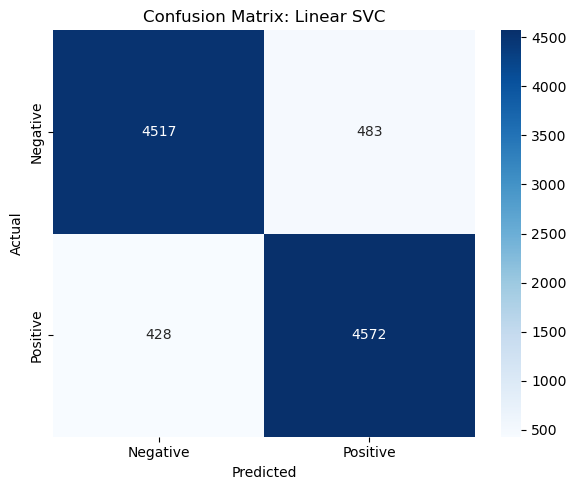

In [25]:
#Confusion matrix
y_pred=best_svc.predict(X_test_tfidf)
cm=confusion_matrix(y_test,y_pred)
fig,ax=plt.subplots(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax,xticklabels=['Negative','Positive'],yticklabels=['Negative','Positive'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix: Linear SVC')
plt.tight_layout()
plt.savefig('../assets/confusion_matrix.png',dpi=150,bbox_inches='tight')
plt.show()

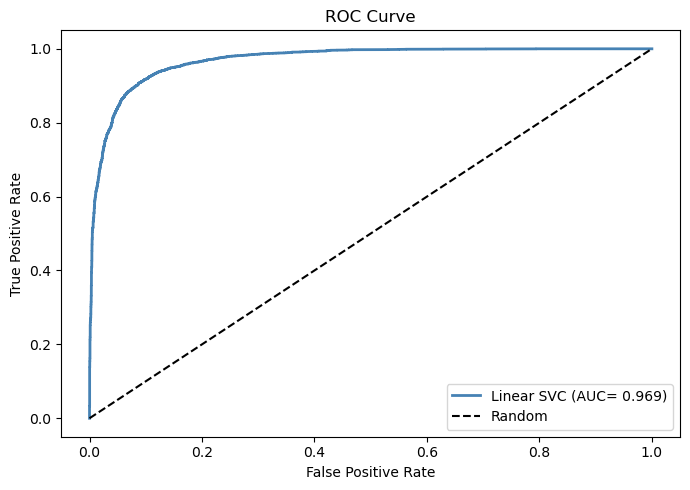

In [29]:
#ROC Curve
y_scores=best_svc.decision_function(X_test_tfidf)
fpr,tpr,_=roc_curve(y_test,y_scores)
auc=roc_auc_score(y_test,y_scores)

fig,ax=plt.subplots(figsize=(7,5))
ax.plot(fpr,tpr,color='steelblue',linewidth=2,label=f'Linear SVC (AUC= {auc:.3f})')
ax.plot([0,1],[0,1],'k--',label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.savefig('../assets/roc_curve.png',dpi=150,bbox_inches='tight')
plt.show()

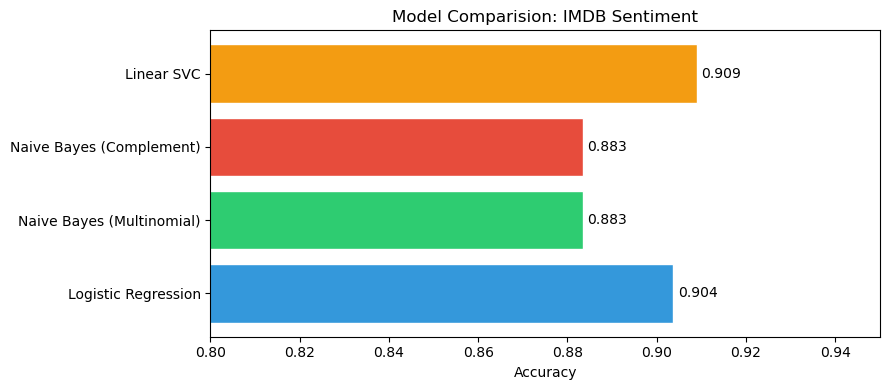

In [33]:
# Model comparision bar chart
results['Linear SVC']=0.9089
fig,ax=plt.subplots(figsize=(9,4))
model_names= list(results.keys())
accuracies=list(results.values())
colors=['#3498db','#2ecc71','#e74c3c','#f39c12']

bars=ax.barh(model_names,accuracies,color=colors,edgecolor='white')
ax.set_xlim(0.80,0.95)
ax.set_xlabel('Accuracy')
ax.set_title('Model Comparision: IMDB Sentiment')

for bar,val in zip(bars,accuracies):
    ax.text(val + 0.001,bar.get_y() + bar.get_height()/2, f'{val:.3f}',va='center',fontsize=10)
plt.tight_layout()
plt.savefig('../assets/model_comparision.png',dpi=150,bbox_inches='tight')
plt.show()

In [35]:
#top features
import json
# using logistic regression for interpretibility instead of linear SVC due to cleaner meaning of corf_
lr_model=models['Logistic Regression']
feature_names=tfidf.get_feature_names_out()
coef=lr_model.coef_[0]

#getting top 20 words for both
top_pos_idx=coef.argsort()[-20:] #end of the array
top_neg_idx=coef.argsort()[:20] #start of the array
features_data={
    'positive':[(feature_names[i],float(coef[i])) for i in reversed(top_pos_idx)],
    'negative':[(feature_names[i],float(coef[i])) for i in top_neg_idx]
}

with open('../model/top_features.json','w') as f:
    json.dump(features_data,f,indent=2)

print("top 5 pos words:")
for word,score in features_data['positive'][:5]:
    print(f"{word}: {score:.3f}")
print("top 5 neg words:")
for word,score in features_data['negative'][:5]:
    print(f"{word}: {score:.3f}")

top 5 pos words:
dark heart: 8.351
character unbelievable: 7.016
fun whole: 5.589
annoying not: 5.179
admittedly: 4.955
top 5 neg words:
little flat: -9.624
although well: -9.174
also think: -7.748
lie film: -6.991
aristocats: -6.400


In [36]:
#saving the models
joblib.dump(tfidf,'../model/tfidf_vectorizer.pkl')
joblib.dump(best_svc,'../model/svc_model.pkl')
joblib.dump(lr_model,'../model/lr_model.pkl')

['../model/lr_model.pkl']